In [287]:
import pandas as pd

In [288]:
df = pd.read_csv('/content/Solar.csv')
df

,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0
...,...,...,...,...,...,...,...,...
8755,31.12.2017-19:00,4.1,0,988.2,-4.8,-0.7,94,0.0
8756,31.12.2017-20:00,2.1,0,987.3,-5.0,-0.3,95,0.0
8757,31.12.2017-21:00,1.8,0,986.7,-5.3,0.2,93,0.0
8758,31.12.2017-22:00,2.2,0,986.0,-5.4,0.3,92,0.0


In [289]:
print (df.shape)
print (df.info())
print (df.describe())

(8760, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date-Hour(NMT)       8760 non-null   object 
 1   WindSpeed            8760 non-null   float64
 2   Sunshine             8760 non-null   int64  
 3   AirPressure          8760 non-null   float64
 4   Radiation            8760 non-null   float64
 5   AirTemperature       8760 non-null   float64
 6   RelativeAirHumidity  8760 non-null   int64  
 7   SystemProduction     8760 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 547.6+ KB
None
         WindSpeed     Sunshine  AirPressure    Radiation  AirTemperature  \
count  8760.000000  8760.000000  8760.000000  8760.000000     8760.000000   
mean      2.639823    11.180479  1010.361781    97.538493        6.978893   
std       1.628754    21.171295    12.793971   182.336029        7.604266   
min    

# **1**

# A

In [290]:
df.isnull().sum()

,0
Date-Hour(NMT),0
WindSpeed,0
Sunshine,0
AirPressure,0
Radiation,0
AirTemperature,0
RelativeAirHumidity,0
SystemProduction,0


Data has no null value

In [291]:
df.duplicated().sum()

0

In [292]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

# B


In [293]:
df['Date-Hour(NMT)'].head()

,Date-Hour(NMT)
0,01.01.2017-00:00
1,01.01.2017-01:00
2,01.01.2017-02:00
3,01.01.2017-03:00
4,01.01.2017-04:00


In [294]:
df['month'] = df['Date-Hour(NMT)'].apply(lambda x: x.split('.')[1]).astype(int)  # Convert to int
df['day'] = df['Date-Hour(NMT)'].apply(lambda x: x.split('.')[0]).astype(int)  # Convert to int
df['Hour'] = df['Date-Hour(NMT)'].apply(lambda x: x.split('-')[1])  # Convert to int
df['Hour'] = df['Hour'].apply(lambda x: x.split(':')[0]).astype(int)  # Convert to int
df['Hour'].head()
print(df)

        Date-Hour(NMT)  WindSpeed  Sunshine  AirPressure  Radiation  \
0     01.01.2017-00:00        0.6         0       1003.8       -7.4   
1     01.01.2017-01:00        1.7         0       1003.5       -7.4   
2     01.01.2017-02:00        0.6         0       1003.4       -6.7   
3     01.01.2017-03:00        2.4         0       1003.3       -7.2   
4     01.01.2017-04:00        4.0         0       1003.1       -6.3   
...                ...        ...       ...          ...        ...   
8755  31.12.2017-19:00        4.1         0        988.2       -4.8   
8756  31.12.2017-20:00        2.1         0        987.3       -5.0   
8757  31.12.2017-21:00        1.8         0        986.7       -5.3   
8758  31.12.2017-22:00        2.2         0        986.0       -5.4   
8759  31.12.2017-23:00        2.4         0        985.6       -5.9   

      AirTemperature  RelativeAirHumidity  SystemProduction  month  day  Hour  
0                0.1                   97               0.0      1 

In [295]:
# Define the mapping dictionary
season_mapping = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

# Apply the mapping to the correct column
df['Seasons'] = df['month'].map(season_mapping)
df.head()

,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,month,day,Hour,Seasons
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0,1,1,0,Winter
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0,1,1,1,Winter
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0,1,1,2,Winter
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0,1,1,3,Winter
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0,1,1,4,Winter


# **2**

In [296]:
df.drop('Date-Hour(NMT)', axis=1, inplace=True)

In [297]:
df.head()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,month,day,Hour,Seasons
0,0.6,0,1003.8,-7.4,0.1,97,0.0,1,1,0,Winter
1,1.7,0,1003.5,-7.4,-0.2,98,0.0,1,1,1,Winter
2,0.6,0,1003.4,-6.7,-1.2,99,0.0,1,1,2,Winter
3,2.4,0,1003.3,-7.2,-1.3,99,0.0,1,1,3,Winter
4,4.0,0,1003.1,-6.3,3.6,67,0.0,1,1,4,Winter


array([[<Axes: title={'center': 'WindSpeed'}>,
        <Axes: title={'center': 'Sunshine'}>,
        <Axes: title={'center': 'AirPressure'}>],
       [<Axes: title={'center': 'Radiation'}>,
        <Axes: title={'center': 'AirTemperature'}>,
        <Axes: title={'center': 'RelativeAirHumidity'}>],
       [<Axes: title={'center': 'SystemProduction'}>,
        <Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'Hour'}>, <Axes: >, <Axes: >]],
      dtype=object)

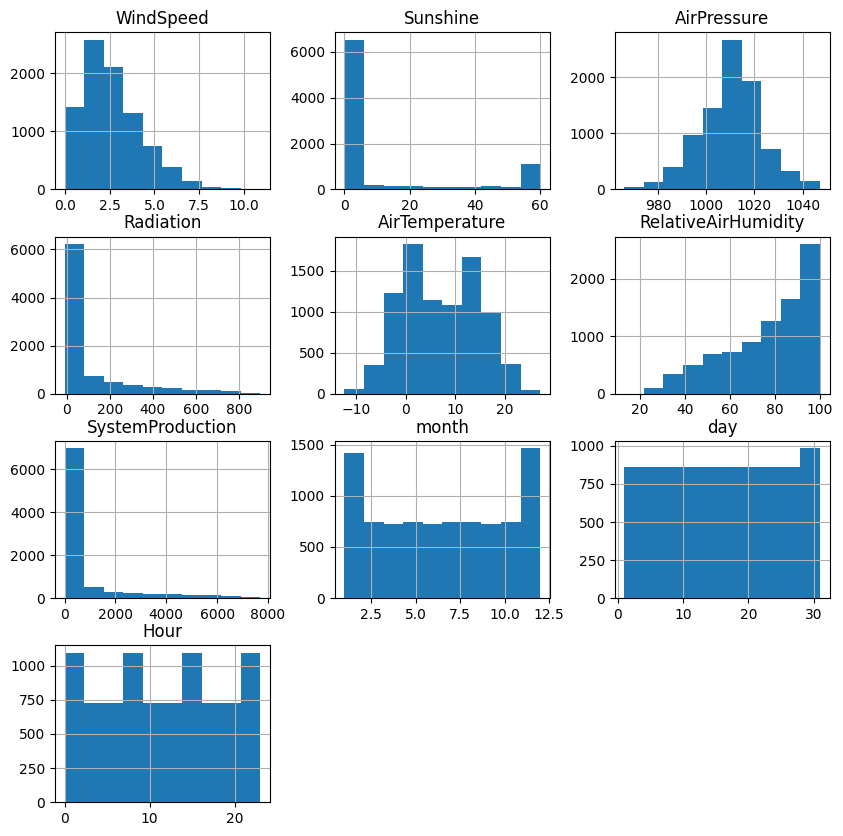

In [298]:
df.hist(figsize=(10, 10))

<Axes: xlabel='SystemProduction', ylabel='Count'>

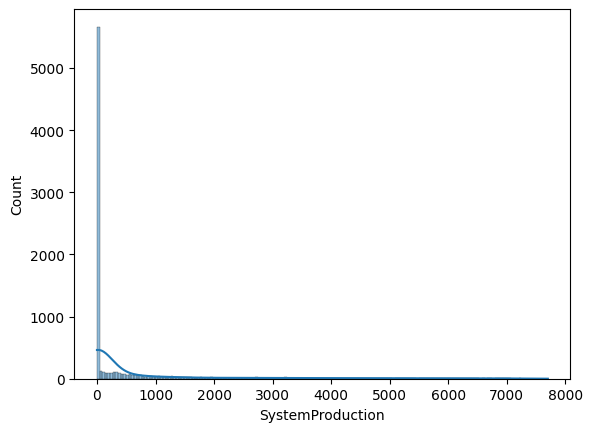

In [299]:
import seaborn as sns
sns.histplot(df['SystemProduction'], kde=True)

we can see thatRadiation and sunshine  and wind speed effect our target

In [300]:
df.columns

Index(['WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 'AirTemperature',
       'RelativeAirHumidity', 'SystemProduction', 'month', 'day', 'Hour',
       'Seasons'],
      dtype='object')

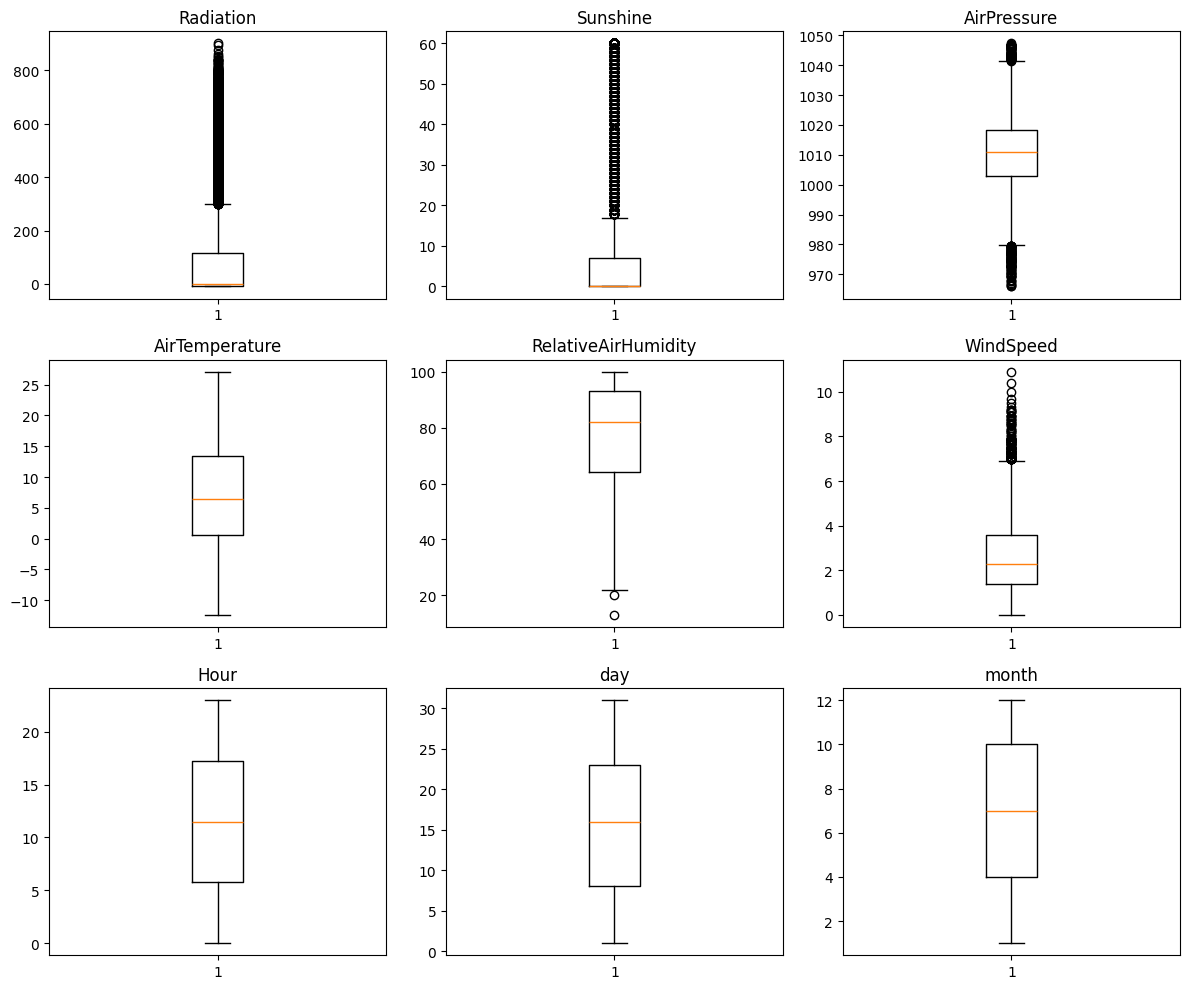

In [301]:
import matplotlib.pyplot as plt
columns = ['Radiation', 'Sunshine', 'AirPressure', 'AirTemperature',
           'RelativeAirHumidity', 'WindSpeed', 'Hour', 'day', 'month']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(columns):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [302]:
df.columns

Index(['WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 'AirTemperature',
       'RelativeAirHumidity', 'SystemProduction', 'month', 'day', 'Hour',
       'Seasons'],
      dtype='object')

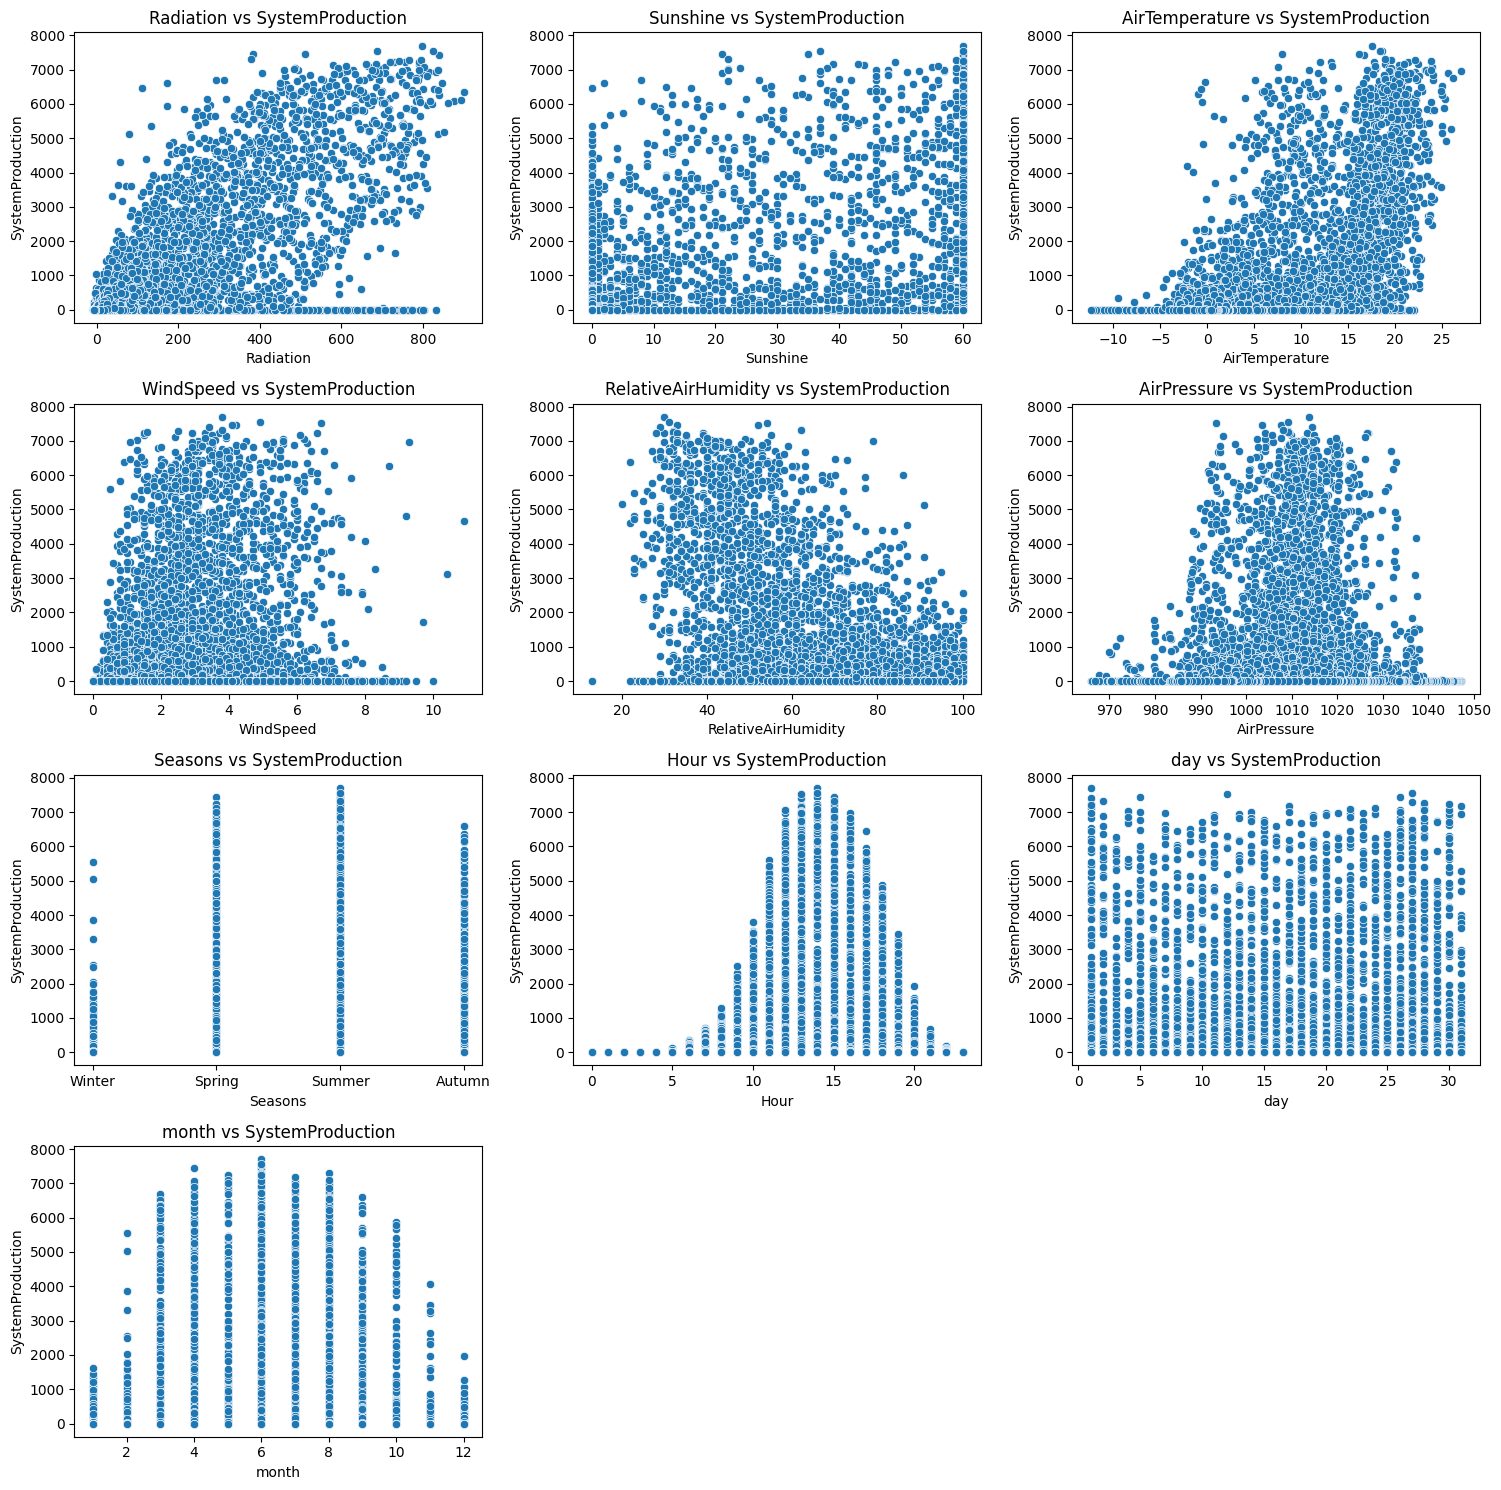

In [303]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Radiation', 'Sunshine', 'AirTemperature', 'WindSpeed', 'RelativeAirHumidity','AirPressure', 'Seasons', 'Hour','day','month']
target = 'SystemProduction'

# Adjust the subplot grid to accommodate 10 plots (e.g., 4 rows x 3 columns)
plt.figure(figsize=(15,15))  # Increased figure height
num_cols = 3  # Number of columns
num_rows = 4  # Number of rows (adjust based on total plots needed)

for i, feature in enumerate(features, 1):
    plt.subplot(num_rows, num_cols, i)  # Changed from (3, 3, i)
    sns.scatterplot(x=df[feature], y=df[target])
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f'{feature} vs {target}')

plt.tight_layout()
plt.show()

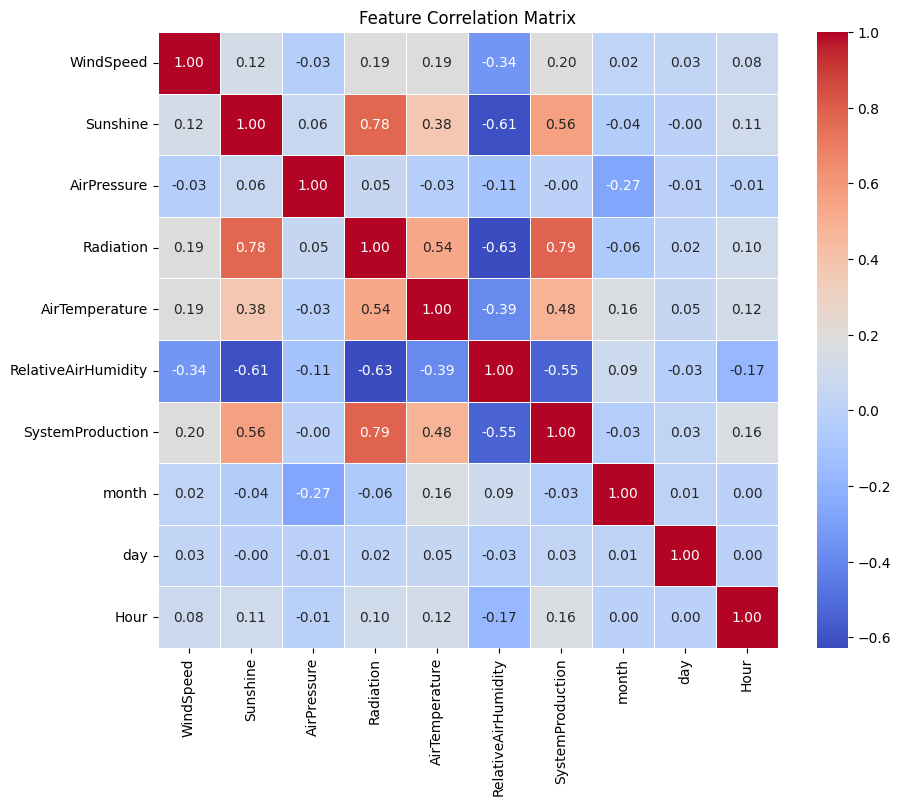

In [304]:
import numpy as np

corr_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# **3**

In [305]:
df.columns

Index(['WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 'AirTemperature',
       'RelativeAirHumidity', 'SystemProduction', 'month', 'day', 'Hour',
       'Seasons'],
      dtype='object')

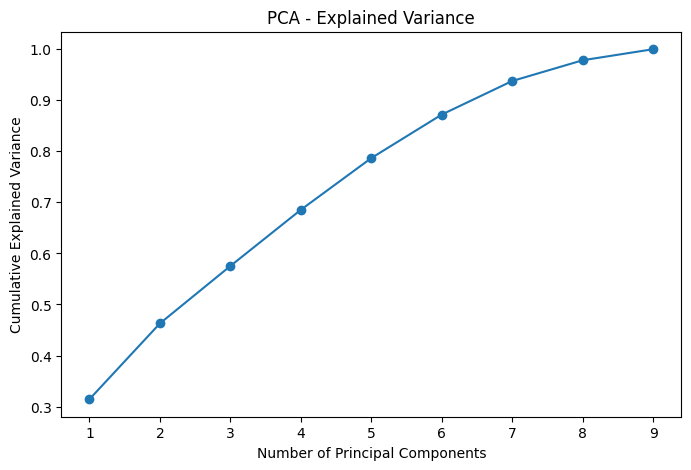

In [306]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

numeric_features = ['WindSpeed', 'Sunshine', 'AirPressure', 'Radiation',
                    'AirTemperature', 'RelativeAirHumidity','day','month','Hour']

# Standardize data (important for PCA)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_features])

# Apply PCA
pca = PCA(n_components=len(numeric_features))  # Keep all components for now
pca.fit(scaled_data)

# Explained variance ratio
plt.figure(figsize=(8,5))
plt.plot(range(1, len(numeric_features)+1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.show()

In [307]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

# Convert SystemProduction into categorical (e.g., high/low production)
df['Production_Category'] = np.where(df['SystemProduction'] > df['SystemProduction'].median(), 'High', 'Low')

# Encode categorical target variable
label_encoder = LabelEncoder()
df['Production_Category'] = label_encoder.fit_transform(df['Production_Category'])

# Select categorical input features (Seasons)
categorical_features = ['Seasons']
df_encoded = pd.get_dummies(df[categorical_features])  # Convert to numeric

# Apply Chi-Square Test
chi2_scores, p_values = chi2(df_encoded, df['Production_Category'])

# Print results
chi2_results = pd.DataFrame({'Feature': df_encoded.columns, 'Chi2 Score': chi2_scores, 'P-Value': p_values})
print(chi2_results.sort_values(by='Chi2 Score', ascending=False))

          Feature  Chi2 Score        P-Value
2  Seasons_Summer  695.700807  2.573926e-153
3  Seasons_Winter  535.144026  2.147080e-118
0  Seasons_Autumn   22.075201   2.621749e-06
1  Seasons_Spring    1.385401   2.391832e-01


Summer and Winter have the strongest impact on system production because they have the highest Chi² scores and extremely small p-values (close to zero).
Autumn has a small but noticeable effect.
Spring does not significantly impact production because its p-value is large (> 0.05).

In [308]:
df.drop('Production_Category', axis=1, inplace=True)

In [309]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Seasons'] = label_encoder.fit_transform(df['Seasons'])

In [310]:
df.head()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,month,day,Hour,Seasons
0,0.6,0,1003.8,-7.4,0.1,97,0.0,1,1,0,3
1,1.7,0,1003.5,-7.4,-0.2,98,0.0,1,1,1,3
2,0.6,0,1003.4,-6.7,-1.2,99,0.0,1,1,2,3
3,2.4,0,1003.3,-7.2,-1.3,99,0.0,1,1,3,3
4,4.0,0,1003.1,-6.3,3.6,67,0.0,1,1,4,3


# **4**

In [311]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   WindSpeed            8760 non-null   float64
 1   Sunshine             8760 non-null   int64  
 2   AirPressure          8760 non-null   float64
 3   Radiation            8760 non-null   float64
 4   AirTemperature       8760 non-null   float64
 5   RelativeAirHumidity  8760 non-null   int64  
 6   SystemProduction     8760 non-null   float64
 7   month                8760 non-null   int64  
 8   day                  8760 non-null   int64  
 9   Hour                 8760 non-null   int64  
 10  Seasons              8760 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 752.9 KB


In [312]:
from sklearn.model_selection import train_test_split

features = df.columns.drop('SystemProduction')
target = 'SystemProduction'

X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

In [313]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

We have a lot of outliers so we are going to use the robust scaler methode

In [314]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_xgb = GridSearchCV(XGBRegressor(objective='reg:squarederror', random_state=42),
                         param_grid=xgb_params, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print("Best XGBoost Parameters:", grid_xgb.best_params_)

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


In [315]:
# Define hyperparameters for Random Forest
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid=rf_params, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best Random Forest Parameters:", grid_rf.best_params_)

Best Random Forest Parameters: {'max_depth': 15, 'n_estimators': 200}


In [316]:
# Train XGBoost model
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=7, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [317]:
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# **5**

In [318]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAE
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Calculate MSE & RMSE
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

# Calculate R² Score
r2_xgb = r2_score(y_test, y_pred_xgb)
r2_rf = r2_score(y_test, y_pred_rf)

# Calculate NRMSE (Normalized RMSE)
nrmse_xgb = mse_xgb/y_test.var()
nrmse_rf =  mse_rf/y_test.var()


# Print results
print(f'XGBoost MAE: {mae_xgb:.4f}, MSE: {mse_xgb:.4f}, RMSE: {rmse_xgb:.4f}, R²: {r2_xgb:.4f}, NRMSE: {nrmse_xgb:.4f}')
print(f'Random Forest MAE: {mae_rf:.4f}, MSE: {mse_rf:.4f}, RMSE: {rmse_rf:.4f}, R²: {r2_rf:.4f}, NRMSE: {nrmse_rf:.4f}')


XGBoost MAE: 198.4391, MSE: 212265.8240, RMSE: 460.7232, R²: 0.8927, NRMSE: 0.1072
Random Forest MAE: 208.8175, MSE: 221667.5803, RMSE: 470.8159, R²: 0.8880, NRMSE: 0.1120
